## <center>K-means Lab</center>

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [2]:
documents = [
    "This little kitty came to play when I was eating at a restaurant.",
    "Merley has the best squooshy kitten belly.",
    "Google Translate app is incredible.",
    "If you open 100 tab in google you get a smiley face.",
    "Best cat photo I've ever taken.",
    "Climbing ninja cat.",
    "Impressed with google map feedback.",
    "Key promoter extension for Google Chrome.",
]

In [3]:
# Data Cleaning
vectorizer = TfidfVectorizer(stop_words='english')

In [4]:
X = vectorizer.fit_transform(documents)
print(vectorizer.vocabulary_)
print(vectorizer.get_feature_names_out())

{'little': 18, 'kitty': 17, 'came': 4, 'play': 24, 'eating': 8, 'restaurant': 26, 'merley': 20, 'best': 3, 'squooshy': 28, 'kitten': 16, 'belly': 2, 'google': 12, 'translate': 31, 'app': 1, 'incredible': 14, 'open': 22, '100': 0, 'tab': 29, 'smiley': 27, 'face': 10, 'cat': 5, 'photo': 23, 've': 32, 'taken': 30, 'climbing': 7, 'ninja': 21, 'impressed': 13, 'map': 19, 'feedback': 11, 'key': 15, 'promoter': 25, 'extension': 9, 'chrome': 6}
['100' 'app' 'belly' 'best' 'came' 'cat' 'chrome' 'climbing' 'eating'
 'extension' 'face' 'feedback' 'google' 'impressed' 'incredible' 'key'
 'kitten' 'kitty' 'little' 'map' 'merley' 'ninja' 'open' 'photo' 'play'
 'promoter' 'restaurant' 'smiley' 'squooshy' 'tab' 'taken' 'translate'
 've']


In [5]:
true_k = 2
model = KMeans(n_clusters=true_k, init='k-means++', max_iter=100, n_init=1)
model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",100
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [6]:
print(model.labels_)

[0 0 0 0 1 1 0 0]


In [7]:
Y = vectorizer.transform(["My cat is hungry."])
prediction = model.predict(Y)
print(prediction)

[1]


In [8]:
print("Top terms per cluster:")
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()
for i in range(true_k):
    print(f"Cluster {i}:")
    for ind in order_centroids[i, :10]:
        print(f" {terms[ind]}")
    print()

Top terms per cluster:
Cluster 0:
 google
 feedback
 translate
 incredible
 map
 app
 impressed
 extension
 promoter
 key

Cluster 1:
 cat
 climbing
 ninja
 ve
 taken
 photo
 best
 smiley
 translate
 play



---

In [9]:
from sklearn.datasets import fetch_20newsgroups

categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
dataset = fetch_20newsgroups(subset='all', categories=categories, shuffle=True, random_state=42)

X_test = dataset.data
X_test_processed = vectorizer.fit_transform(X_test)

In [10]:
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
# X_2d = svd.fit_transform(X_test_processed)
X_2d = svd.fit_transform(X)


3 | Top terms per cluster:
Cluster 0:
    002
    001
    001125
    0000
    000406
    0010
    001004
    001442
    001642
    000005102000

Cluster 1:
    000iu
    000821
    003258u19250
    000ug
    0010580b
    000
    000mg
    000410
    001631
    000usd

Cluster 2:
    0001
    00014
    001200201pixel
    0033
    003
    0014
    0000001200
    00196
    003258u19250
    001442



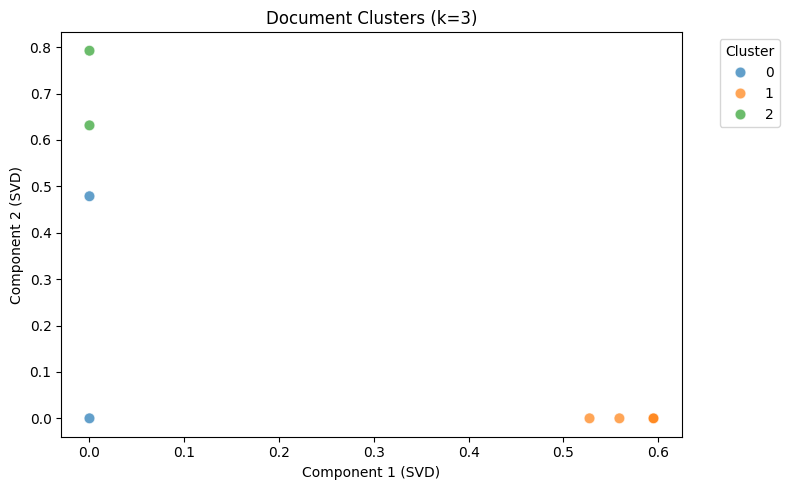


4 | Top terms per cluster:
Cluster 0:
    001442
    000005102000
    001642
    001004
    0010
    000406
    0033
    002
    0028
    001631

Cluster 1:
    0001
    0000001200
    001200201pixel
    00014
    0033
    0014
    003
    001
    002
    0000

Cluster 2:
    000iu
    000821
    003258u19250
    000ug
    0010580b
    000
    000mg
    001326
    00196
    0007

Cluster 3:
    001631
    000410
    000100255pixel
    000usd
    000iu
    0033
    003258u19250
    0028
    003
    0014



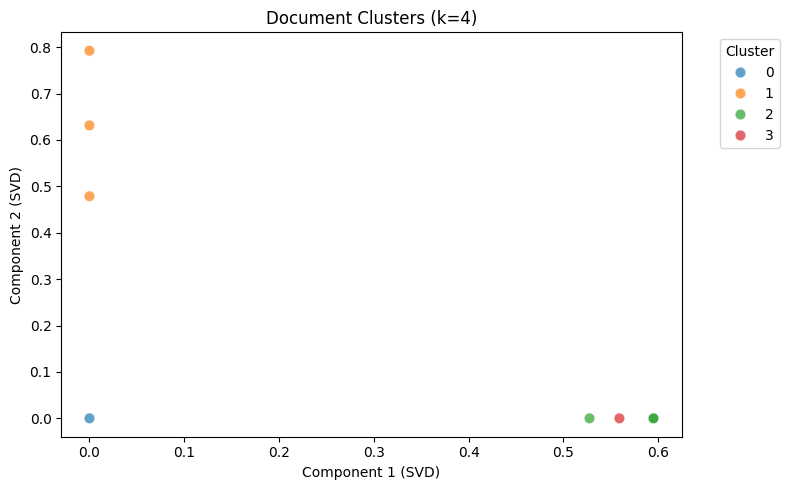


5 | Top terms per cluster:
Cluster 0:
    0001
    00014
    001200201pixel
    0033
    003
    0014
    0000001200
    00196
    003258u19250
    001442

Cluster 1:
    000iu
    000821
    003258u19250
    000ug
    0010580b
    000
    000mg
    000410
    001631
    000usd

Cluster 2:
    001442
    000005102000
    001642
    001004
    0010
    000406
    0033
    002
    0028
    001631

Cluster 3:
    002
    001
    001125
    0000
    0000001200
    0033
    001642
    00196
    003258u19250
    001442

Cluster 4:
    0028
    00
    00196
    001326
    0007
    000iu
    0033
    002
    003
    001442



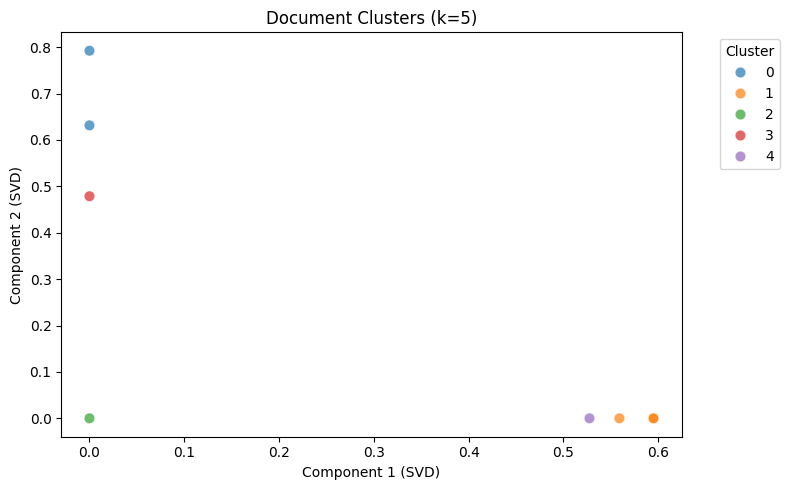


6 | Top terms per cluster:
Cluster 0:
    001631
    000410
    000100255pixel
    000usd
    000iu
    0033
    003258u19250
    0028
    003
    0014

Cluster 1:
    0001
    00014
    001200201pixel
    0033
    003
    0014
    0000001200
    00196
    003258u19250
    001442

Cluster 2:
    000iu
    000821
    003258u19250
    000ug
    0010580b
    000
    000mg
    0033
    0028
    001442

Cluster 3:
    001442
    000005102000
    001642
    001004
    0010
    000406
    0033
    002
    0028
    001631

Cluster 4:
    0028
    00
    00196
    001326
    0007
    000iu
    0033
    002
    003
    001442

Cluster 5:
    002
    001
    001125
    0000
    0000001200
    0033
    001642
    00196
    003258u19250
    001442



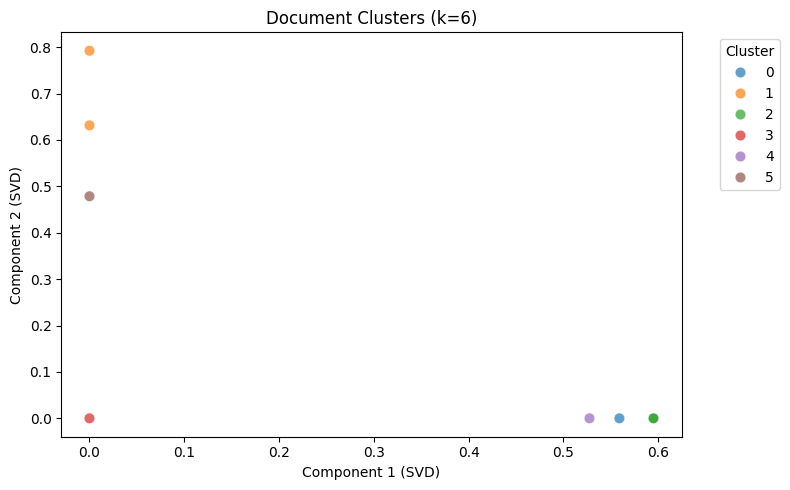


7 | Top terms per cluster:
Cluster 0:
    001631
    000410
    000100255pixel
    000usd
    000iu
    0033
    003258u19250
    0028
    003
    0014

Cluster 1:
    001442
    000005102000
    001642
    001004
    0010
    000406
    0033
    002
    0028
    001631

Cluster 2:
    0001
    00014
    001200201pixel
    0033
    003
    0014
    0000001200
    00196
    003258u19250
    001442

Cluster 3:
    0010580b
    000821
    000mg
    000iu
    0033
    00196
    003258u19250
    0028
    003
    001442

Cluster 4:
    002
    001
    001125
    0000
    0000001200
    0033
    001642
    00196
    003258u19250
    001442

Cluster 5:
    0028
    00
    00196
    001326
    0007
    000iu
    0033
    002
    003
    001442

Cluster 6:
    003258u19250
    000
    000ug
    000iu
    0033
    00196
    003
    0028
    002
    0014



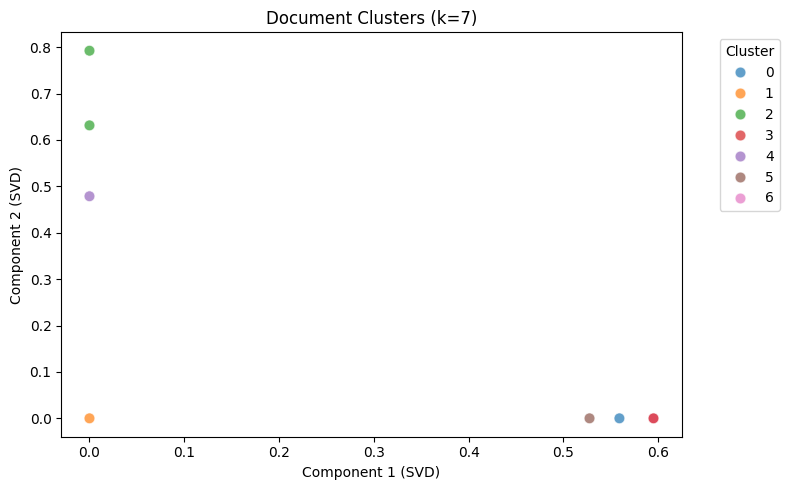

In [11]:
inertia_values = []
silhouette_scores = []

for k in range(3, 8):
    model = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=1)
    # cluster_labels = model.fit_predict(X_test_processed)
    cluster_labels = model.fit_predict(X)

    inertia_values.append(model.inertia_)

    # score = silhouette_score(X_test_processed, cluster_labels)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

    print(f"\n{'='*40}")
    print(f"{k} | Top terms per cluster:")
    order_centroids = model.cluster_centers_.argsort()[:, ::-1]
    terms = vectorizer.get_feature_names_out()

    for i in range(k):
        print(f"Cluster {i}:")
        for ind in order_centroids[i, :10]:
            print(f"    {terms[ind]}")
        print()

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        x=X_2d[:, 0],
        y=X_2d[:, 1],
        hue=cluster_labels,
        palette='tab10',
        s=60,
        alpha=0.7
    )

    plt.title(f"Document Clusters (k={k})")
    plt.xlabel("Component 1 (SVD)")
    plt.ylabel("Component 2 (SVD)")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.show()

### Q: How can we determine the optimal value for $k$?
A: We can optimize $k$ by plotting the model's performance across different cluster sizes. We typically use the Elbow Method, looking for an inflection point where the inertia stops dropping rapidly, or the Silhouette Score, looking for the maximum score which indicates highly distinct clusters.


EVALUATION METRICS:


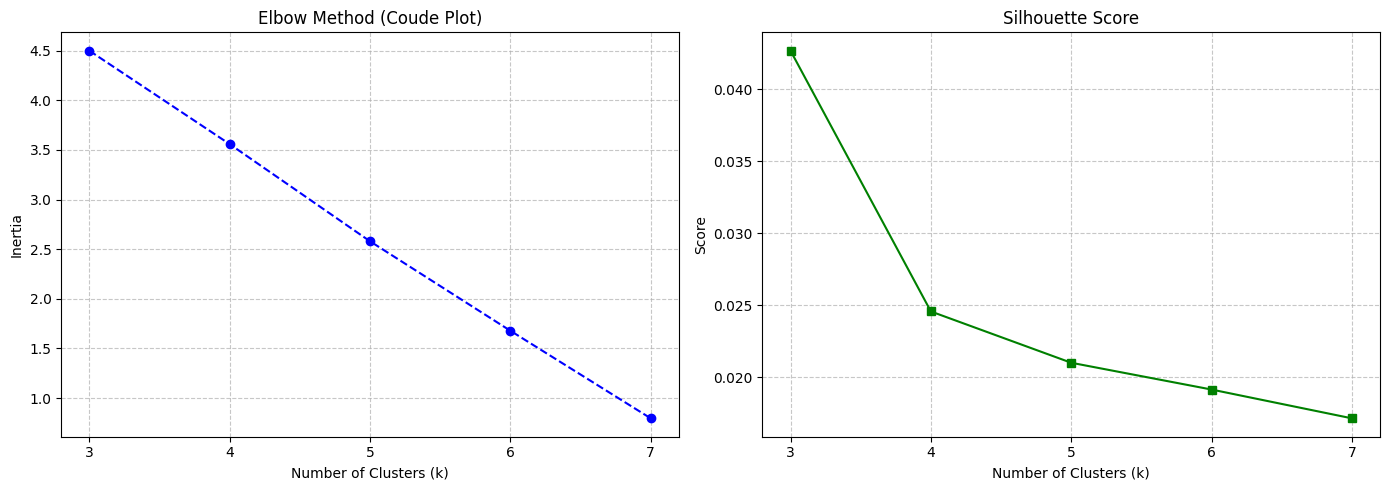

In [13]:
print(f"\n{'='*40}")
print("EVALUATION METRICS:")

k_range = range(3, 8)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia_values, marker='o', linestyle='--', color='b')
ax1.set_title("Elbow Method (Coude Plot)")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title("Silhouette Score")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Score")
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Conclusion: Optimal Cluster Size (k = 6)

Based on the updated evaluation metrics, the most optimal number of clusters for this dataset is **k = 6**. 

* **Silhouette Score:** The score demonstrates a clear and distinct peak at k = 6, reaching its maximum value across the tested range before sharply dropping at k = 7. This peak indicates that 6 clusters provide the best mathematical balance of cohesion within the clusters and separation between them.
* **Elbow Method (Inertia):** The inertia plot displays a steady, almost linear descent from k = 3 through k = 7 without a pronounced "elbow" or sudden flattening. Because high-dimensional text data often lacks a clear elbow in inertia, we rely on the definitive maximum shown in the Silhouette Score to confidently select k = 6.